In [16]:
%cd /content
!git clone https://github.com/Priyadh1/syntecxhub_credit_card_fraud_detection.git
%cd /content/syntecxhub_credit_card_fraud_detection
!ls -lh

/content
fatal: destination path 'syntecxhub_credit_card_fraud_detection' already exists and is not an empty directory.
/content/syntecxhub_credit_card_fraud_detection
total 6.6M
-rw-r--r-- 1 root root 6.2M Oct  6 04:26 creditcard_small.csv
-rw-r--r-- 1 root root 413K Oct  6 04:55 fraud_xgb_smote_model.pkl
-rw-r--r-- 1 root root   40 Oct  6 04:26 README.md
-rw-r--r-- 1 root root  935 Oct  6 04:55 scaler.pkl


In [17]:
import pandas as pd

df = pd.read_csv("creditcard_small.csv")
print(df.shape)
df.head()

(25492, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,38111.0,1.18447,0.17642,0.23681,1.15593,-0.41435,-0.98735,0.17278,-0.16918,0.17119,...,0.03141,0.00679,-0.11051,0.36477,0.63340,-0.32744,-0.00031,0.02295,34.84,0
1,74284.0,1.23605,0.28663,0.18687,0.50158,-0.16348,-0.56294,-0.03021,-0.02967,-0.18853,...,-0.25860,-0.78677,0.07744,-0.03985,0.22611,0.09765,-0.02806,0.01712,1.98,0
2,58439.0,-4.17432,3.79573,-1.63115,-0.06402,-2.55582,-1.36716,-1.83691,2.97837,-0.44500,...,-0.11177,-0.80630,0.37783,0.33804,0.27657,0.11282,0.02523,0.03309,9.03,0
3,48267.0,1.09204,-0.33308,0.86283,0.57924,-0.56797,0.56369,-0.59743,0.19892,0.55748,...,-0.05041,-0.05687,-0.15044,-0.45371,0.35651,0.34297,0.00852,0.02050,64.99,0
4,120633.0,1.84411,-1.43044,-0.63511,-0.88423,-1.07630,-0.18806,-0.85018,-0.00187,-0.21841,...,0.08235,-0.09556,0.19585,-0.47642,-0.53432,-0.49185,-0.01457,-0.02786,161.00,0


In [18]:
# ===== STEP 3: BASIC EDA =====

# 3.1 Column names, data types, and non-null counts
df.info()

# 3.2 Missing values in each column
print("\nMissing values:", df.isnull().sum().sum())

# 3.3 Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# 3.4 Summary statistics of Time and Amount
df[["Time", "Amount"]].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25492 entries, 0 to 25491
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    25492 non-null  float64
 1   V1      25492 non-null  float64
 2   V2      25492 non-null  float64
 3   V3      25492 non-null  float64
 4   V4      25492 non-null  float64
 5   V5      25492 non-null  float64
 6   V6      25492 non-null  float64
 7   V7      25492 non-null  float64
 8   V8      25492 non-null  float64
 9   V9      25492 non-null  float64
 10  V10     25492 non-null  float64
 11  V11     25492 non-null  float64
 12  V12     25492 non-null  float64
 13  V13     25492 non-null  float64
 14  V14     25492 non-null  float64
 15  V15     25492 non-null  float64
 16  V16     25492 non-null  float64
 17  V17     25492 non-null  float64
 18  V18     25492 non-null  float64
 19  V19     25492 non-null  float64
 20  V20     25492 non-null  float64
 21  V21     25492 non-null  float64
 22

,Time,Amount
count,25492.000000,25492.000000
mean,94557.474776,86.556449
std,47456.259413,214.510284
min,0.000000,0.000000
25%,54286.750000,5.360000
50%,84546.500000,21.800000
75%,139065.500000,77.000000
max,172768.000000,6511.000000


Class
0    25000
1      492
Name: count, dtype: int64

Fraud percentage: 1.93%


/tmp/ipykernel_578/2644648864.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Class", data=df, palette=["green", "red"])


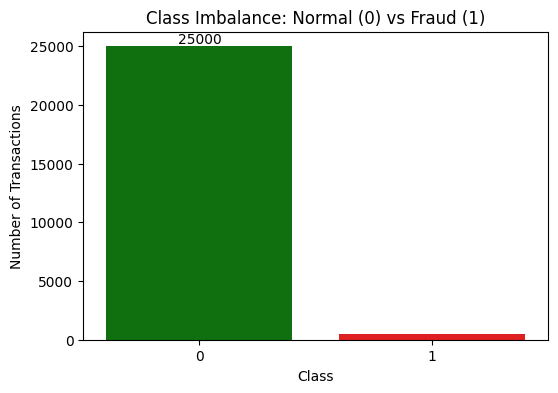

In [19]:
# ===== STEP 4: VISUALIZE CLASS IMBALANCE =====
import matplotlib.pyplot as plt
import seaborn as sns

# 4.1 Count of normal (0) vs fraud (1)
counts = df["Class"].value_counts()
print(counts)
print("\nFraud percentage: {:.2f}%".format(df["Class"].mean() * 100))

# 4.2 Bar chart
plt.figure(figsize=(6, 4))
ax = sns.countplot(x="Class", data=df, palette=["green", "red"])
ax.bar_label(ax.containers[0])
plt.title("Class Imbalance: Normal (0) vs Fraud (1)")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.show()

In [20]:
# ===== STEP 5: TRAIN/TEST SPLIT + SCALING =====
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 5.1 Separate features (X) and target (y)
X = df.drop("Class", axis=1)
y = df["Class"]

# 5.2 Split 80% train / 20% test
# stratify=y keeps the same fraud % in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5.3 Scale Time and Amount (V1-V28 are already scaled)
# fit on TRAIN only, then apply to test
scaler = StandardScaler()
X_train[["Time", "Amount"]] = scaler.fit_transform(X_train[["Time", "Amount"]])
X_test[["Time", "Amount"]] = scaler.transform(X_test[["Time", "Amount"]])

# 5.4 Check
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("\nFraud in train:", y_train.sum(), "| Fraud in test:", y_test.sum())

Train shape: (20393, 30) | Test shape: (5099, 30)

Fraud in train: 394 | Fraud in test: 98


In [21]:
# ===== STEP 6: BASELINE RANDOM FOREST (NO SMOTE) =====
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 6.1 Train
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)

# 6.2 Predict
y_pred = rf_base.predict(X_test)
y_prob = rf_base.predict_proba(X_test)[:, 1]

# 6.3 Evaluate
print(classification_report(y_test, y_pred, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

              precision    recall  f1-score   support

           0      0.997     1.000     0.998      5001
           1      1.000     0.837     0.911        98

    accuracy                          0.997      5099
   macro avg      0.998     0.918     0.955      5099
weighted avg      0.997     0.997     0.997      5099

Confusion matrix:
 [[5001    0]
 [  16   82]]
ROC-AUC: 0.9694


In [22]:
# ===== STEP 7: APPLY SMOTE ON TRAINING DATA ONLY =====
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE

# 7.1 Class counts BEFORE SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

# 7.2 Apply SMOTE (creates synthetic fraud rows until fraud = normal)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# 7.3 Class counts AFTER SMOTE
print("\nAfter SMOTE:")
print(y_train_sm.value_counts())
print("\nNew train shape:", X_train_sm.shape)

Before SMOTE:
Class
0    19999
1      394
Name: count, dtype: int64

After SMOTE:
Class
0    19999
1    19999
Name: count, dtype: int64

New train shape: (39998, 30)


In [23]:
# ===== STEP 8: RANDOM FOREST WITH SMOTE =====
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_sm, y_train_sm)   # trained on SMOTE data

# Test on the ORIGINAL (untouched) test set
y_pred_sm = rf_smote.predict(X_test)
y_prob_sm = rf_smote.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_sm, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_sm))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_sm), 4))

              precision    recall  f1-score   support

           0      0.997     0.999     0.998      5001
           1      0.955     0.867     0.909        98

    accuracy                          0.997      5099
   macro avg      0.976     0.933     0.954      5099
weighted avg      0.997     0.997     0.997      5099

Confusion matrix:
 [[4997    4]
 [  13   85]]
ROC-AUC: 0.969


In [24]:
# ===== STEP 9: XGBOOST WITH SMOTE =====
from xgboost import XGBClassifier

xgb_smote = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    eval_metric="logloss", random_state=42, n_jobs=-1
)
xgb_smote.fit(X_train_sm, y_train_sm)   # trained on SMOTE data

y_pred_x = xgb_smote.predict(X_test)
y_prob_x = xgb_smote.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_x, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_x))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_x), 4))

              precision    recall  f1-score   support

           0      0.998     0.998     0.998      5001
           1      0.905     0.878     0.891        98

    accuracy                          0.996      5099
   macro avg      0.951     0.938     0.945      5099
weighted avg      0.996     0.996     0.996      5099

Confusion matrix:
 [[4992    9]
 [  12   86]]
ROC-AUC: 0.9734



**Why this result is valid:**
- SMOTE was applied **only to the training data**. The test set was never resampled, so it reflects real-world imbalance and no synthetic rows leaked into it.
- The scaler was fitted on the training data only and then applied to the test data, so no information leaked from test to train.
- Accuracy is not used as the main metric, because on imbalanced data a model can reach about 99% accuracy by predicting "not fraud" every time. Precision, recall, F1 and ROC-AUC on the fraud class are used instead.
- All models (Random Forest baseline, Random Forest + SMOTE, XGBoost + SMOTE) are evaluated on the same test set, so the comparison is fair.

**Results (fraud class, 98 frauds in test set):**

| Metric | RF baseline | RF + SMOTE | XGBoost + SMOTE |
|---|---|---|---|
| Precision | 1.000 | 0.955 | 0.905 |
| Recall | 0.837 | 0.867 | 0.878 |
| F1-score | 0.911 | 0.909 | 0.891 |
| ROC-AUC | 0.969 | 0.969 | 0.973 |
| Frauds missed | 16 | 13 | 12 |
| False alarms | 0 | 4 | 9 |

**Interpretation:**
XGBoost with SMOTE catches the most frauds (86 of 98) and has the highest ROC-AUC, but it also raises more false alarms (9). SMOTE shifts the tradeoff toward higher recall at the cost of some precision. The differences between models are small (a few transactions), because the test set contains only 98 frauds.



Average precision (PR-AUC): 0.9231


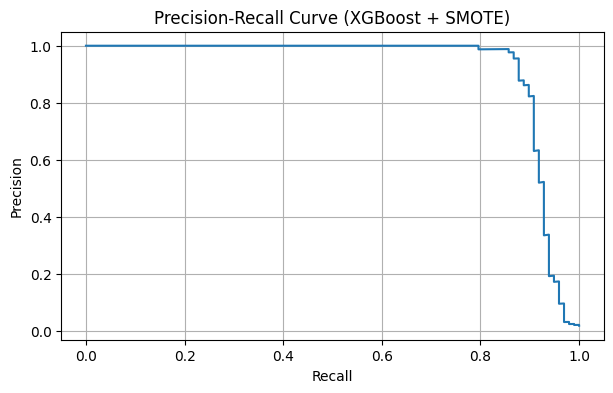


Threshold | Precision | Recall | Frauds missed | False alarms
   0.1    |   0.604   | 0.918  |        8      |      59
   0.3    |   0.838   | 0.898  |       10      |      17
   0.5    |   0.905   | 0.878  |       12      |       9
   0.7    |   0.935   | 0.878  |       12      |       6
   0.9    |   0.988   | 0.847  |       15      |       1


In [25]:
# ===== STEP 10: PRECISION-RECALL TRADEOFF + THRESHOLDS =====
import numpy as np
from sklearn.metrics import precision_recall_curve, average_precision_score

probs = y_prob_x   # XGBoost probabilities (use y_prob_sm for Random Forest)

# 10.1 Precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, probs)
print("Average precision (PR-AUC):", round(average_precision_score(y_test, probs), 4))

plt.figure(figsize=(7, 4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost + SMOTE)")
plt.grid(True)
plt.show()

# 10.2 What happens at different thresholds?
print("\nThreshold | Precision | Recall | Frauds missed | False alarms")
for t in [0.1, 0.3, 0.5, 0.7, 0.9]:
    pred = (probs >= t).astype(int)
    tp = ((pred == 1) & (y_test == 1)).sum()
    fp = ((pred == 1) & (y_test == 0)).sum()
    fn = ((pred == 0) & (y_test == 1)).sum()
    p = tp / (tp + fp) if (tp + fp) else 0
    r = tp / (tp + fn)
    print(f"   {t:.1f}    |   {p:.3f}   | {r:.3f}  |      {fn:3d}      |     {fp:3d}")

## Step 10: Precision vs Recall Tradeoff and Business Threshold

**What this step does:**
The model outputs a fraud probability for each transaction. By default, anything at or above 0.5 is flagged as fraud. I tested thresholds from 0.1 to 0.9 to see how precision and recall change.

> Add blockquote



**Results (XGBoost + SMOTE, 98 frauds in test set):**

| Threshold | Precision | Recall | Frauds missed | False alarms |
|---|---|---|---|---|
| 0.1 | 0.604 | 0.918 | 8 | 59 |
| 0.3 | 0.838 | 0.898 | 10 | 17 |
| 0.5 | 0.905 | 0.878 | 12 | 9 |
| 0.7 | 0.935 | 0.878 | 12 | 6 |
| 0.9 | 0.988 | 0.847 | 15 | 1 |

**Tradeoff:**
Lowering the threshold increases recall (more fraud caught) but lowers precision (more genuine customers flagged). Raising it does the opposite.

**Business decision:**
A missed fraud usually costs more than a manual review of a flagged transaction. Assuming a missed fraud costs about 10 times more than a false alarm, a threshold of **0.3** gives the lowest total cost (10 missed x 10 + 17 false alarms = 117, versus 129 at the default 0.5). If both errors cost about the same, a threshold of 0.7 is better.

**Limitation:**
Thresholds were evaluated on the test set, which has only 98 frauds, so differences are small. In production the threshold should be chosen on a separate validation set.

In [26]:
# ===== STEP 11: SAVE MODEL AND SCALER =====
import joblib

joblib.dump(xgb_smote, "fraud_xgb_smote_model.pkl")
joblib.dump(scaler, "scaler.pkl")

!ls -lh *.pkl

-rw-r--r-- 1 root root 413K Oct  6 05:03 fraud_xgb_smote_model.pkl
-rw-r--r-- 1 root root  935 Oct  6 05:03 scaler.pkl
